In [103]:
import dttxml
import matplotlib.pyplot as plt


data = dttxml.DiagAccess('../../data/ham4/ham4_all_sensors_20250228.xml')

asd_sts = data.asd("L1:ISI-GND_STS_ITMY_Y_DQ").asd
asd_gs13 = data.asd("L1:ISI-HAM4_BLND_GS13Y_IN1_DQ").asd
asd_cps = data.asd("L1:ISI-HAM4_BLND_CPSY_IN1_DQ").asd
f = data.asd("L1:ISI-HAM4_BLND_CPSY_IN1_DQ").FHz
coh_sts_l4c = data.coh("L1:ISI-GND_STS_ITMY_Y_DQ", "L1:ISI-HAM4_FF_Y_IN1_DQ").coh

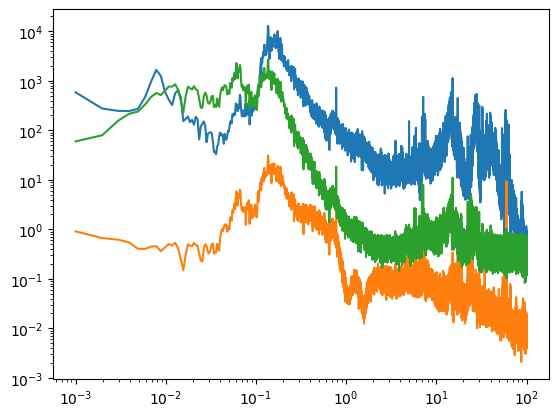

In [104]:
# Raw data
plt.loglog(f, asd_sts)
plt.loglog(f, asd_gs13)
plt.loglog(f, asd_cps)

In [105]:
import control
import numpy as np

# Calibrate raw data to meters

s = control.tf("s")
sts_cal = 1e-9 * 1/s

wn = 1*2*np.pi
q = 1/np.sqrt(2)
gs13_cal = (s**2 + wn/q*s + wn**2) / s**3 * 1e-9

cps_cal = 1e-9


asd_sts = asd_sts * abs(sts_cal(1j*2*np.pi*f))
asd_gs13 = asd_gs13 * abs(gs13_cal(1j*2*np.pi*f))
asd_cps = asd_cps * cps_cal

In [106]:
n_sts = (asd_sts**2 * (1-coh_sts_l4c**.5))**.5
n_sts_ = n_sts.copy()

In [107]:
xg = asd_sts.copy()

xg[f<0.043] = asd_sts[f>0.043][0]
xg_ = xg.copy()
xg[f>1] = asd_sts[f<1][-1]

n_sts[f<0.003] = n_sts[f>0.003][0]
n_sts[f>1] = n_sts[f<1][-1]


In [108]:
f_ = np.logspace(-3, 2, 1024)

xg = np.interp(f_, f, xg)
n_sts = np.interp(f_, f, n_sts)

In [109]:
import kontrol

# np.random.seed(123)
xg_fit = kontrol.curvefit.spectrum_fit(f_, xg, nzero=4, npole=4)

In [117]:
kontrol

<module 'kontrol' from '/home/terrencetec/miniconda3/envs/kontrol/lib/python3.14/site-packages/kontrol/__init__.py'>

In [110]:
n_sts_fit = kontrol.curvefit.spectrum_fit(f_, n_sts, nzero=3, npole=3)

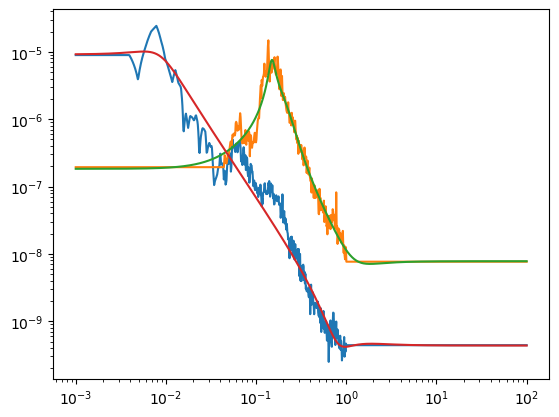

In [111]:
# plt.loglog(f, asd_sts)
plt.loglog(f_, n_sts)
plt.loglog(f_, xg)
plt.loglog(f_, abs(xg_fit(1j*2*np.pi*f_)))
plt.loglog(f_, abs(n_sts_fit(1j*2*np.pi*f_)))
# plt.loglog(f, asd_gs13)
# plt.loglog(f, asd_cps)

In [112]:
sc = kontrol.ComplementaryFilter()

sc.noise2 = n_sts_fit
sc.noise1 = xg_fit
sc.weight2 = 1/xg_fit
sc.weight1 = 1/n_sts_fit

h_sc_, h_sc = sc.hinfsynthesis()

In [113]:
w_c = 0.003*2*np.pi
prefilter = s**3 / (s+w_c)**3

h_sc_p = h_sc * prefilter
h_sc_p_ = 1 - h_sc_p

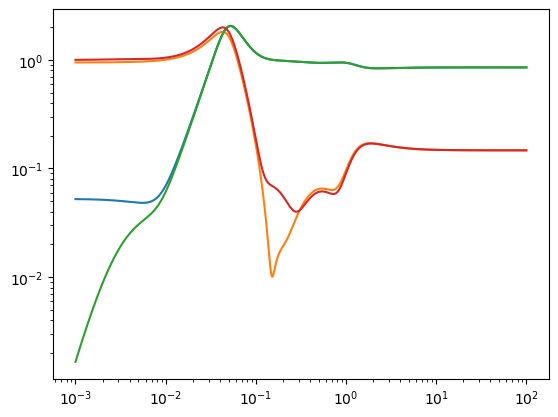

In [114]:
plt.loglog(f_, abs(h_sc(1j*2*np.pi*f_)))
plt.loglog(f_, abs(h_sc_(1j*2*np.pi*f_)))

plt.loglog(f_, abs(h_sc_p(1j*2*np.pi*f_)))
plt.loglog(f_, abs(h_sc_p_(1j*2*np.pi*f_)))

In [115]:
def noise_model(f, na, nb, a, b):
    noise = ((na/f**a)**2+(nb/f**b)**2)**.5
    return noise

    
n_ade1_params = [1*10**-10.0625, 2e-10, 0.75, 0]
n_cps = noise_model(f, *n_ade1_params)
n_sc = np.sqrt(n_cps**2 + abs((1-h_sc_p(1j*2*np.pi*f)))**2*xg_**2 + abs(h_sc_p(1j*2*np.pi*f))**2*n_sts_**2)

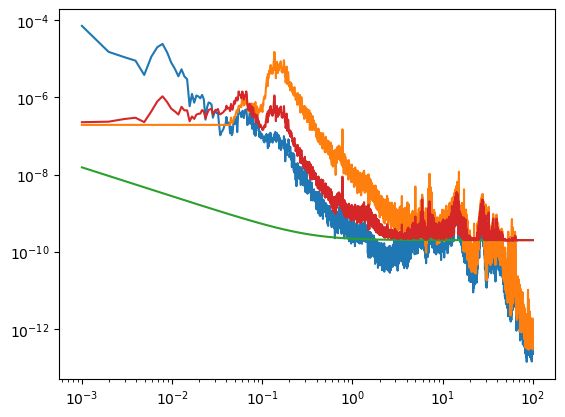

In [116]:
plt.loglog(f, n_sts_)
plt.loglog(f, xg_)
plt.loglog(f, n_cps)
plt.loglog(f, n_sc)